In [34]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/saurabhshahane/fake-news-classification/WELFake_Dataset.csv


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

In [36]:
df = pd.read_csv("/kaggle/input/datasets/saurabhshahane/fake-news-classification/WELFake_Dataset.csv")

In [37]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [38]:
df.shape

(72134, 4)

In [39]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [41]:
df.drop(columns=["Unnamed: 0"], inplace=True)

print("Shape:", df.shape)
print(df["label"].value_counts())

Shape: (72134, 3)
label
1    37106
0    35028
Name: count, dtype: int64


In [42]:
df["title"] = df["title"].fillna("")
df["text"]  = df["text"].fillna("")

In [43]:
df["content"] = df["title"] + " " + df["text"]

In [44]:
def preprocess(text):
    text = text.lower()                                      # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)              # remove URLs
    text = re.sub(r"\d+", "", text)                          # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()                # remove extra spaces
    return text

df["clean_content"] = df["content"].apply(preprocess)
print(df["clean_content"].iloc[0][:200])


Sample after preprocessing:
law enforcement on high alert following threats against cops and whites on by blacklivesmatter and fyf terrorists video no comment is expected from barack obama members of the fyf or fukyoflag and bla


In [52]:
df.shape

(72134, 5)

In [45]:
X = df["clean_content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



Train size : 57707
Test  size : 14427


In [46]:
tfidf = TfidfVectorizer(
    stop_words="english",   # remove common words (the, is, at...)
    max_features=50000,     # top 50k words only
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=2,               # ignore very rare words
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f"\nVocabulary size : {len(tfidf.vocabulary_)}")
print(f"Matrix shape    : {X_train_vec.shape}")


Vocabulary size : 50000
Matrix shape    : (57707, 50000)


In [47]:
model = MultinomialNB(alpha=1.0)   # alpha = Laplace smoothing
model.fit(X_train_vec, y_train)


MultinomialNB()

In [48]:
y_pred = model.predict(X_test_vec)

print("Accuracy ")
print(f"{accuracy_score(y_test, y_pred):.4f}")

print(" Classification Report ")
print(classification_report(y_test, y_pred,
      target_names=["Real (0)", "Fake (1)"]))


── Accuracy ──
0.8763

── Classification Report ──
              precision    recall  f1-score   support

    Real (0)       0.89      0.86      0.87      7006
    Fake (1)       0.87      0.90      0.88      7421

    accuracy                           0.88     14427
   macro avg       0.88      0.88      0.88     14427
weighted avg       0.88      0.88      0.88     14427



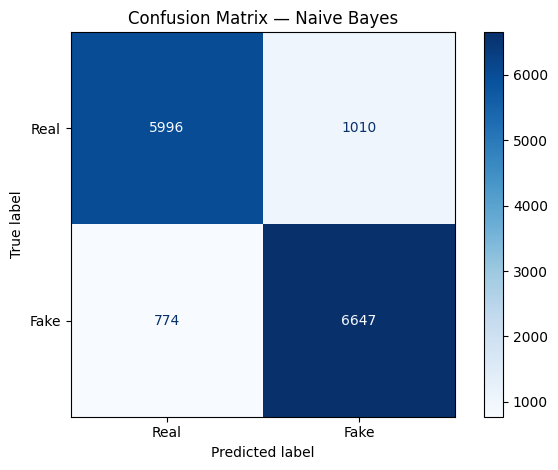

In [49]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Real", "Fake"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Naive Bayes")
plt.tight_layout()
plt.show()

In [50]:
feature_names = tfidf.get_feature_names_out()

for i, label in enumerate(["Real", "Fake"]):
    top_idx = np.argsort(model.feature_log_prob_[i])[-15:]
    top_words = [feature_names[j] for j in top_idx]
    print(f"\nTop 15 words → {label}: {top_words}")


Top 15 words → Real: ['party', 'united', 'clinton', 'republican', 'states', 'people', 'government', 'house', 'state', 'new', 'reuters', 'president', 'mr', 'trump', 'said']

Top 15 words → Fake: ['new', 'election', 'news', 'donald trump', 'donald', 'like', 'said', 'president', 'just', 'obama', 'people', 'video', 'hillary', 'clinton', 'trump']


In [51]:
def predict_news(text):
    cleaned  = preprocess(text)
    vec      = tfidf.transform([cleaned])
    pred     = model.predict(vec)[0]
    proba    = model.predict_proba(vec)[0]
    label    = "FAKE" if pred == 1 else "REAL"
    print(f"\nPrediction : {label}")
    print(f"Confidence → Real: {proba[0]:.2%}  |  Fake: {proba[1]:.2%}")

predict_news("NASA confirms water found on the surface of Mars.")
predict_news("Government secretly replacing birds with surveillance drones!")


Prediction : 🔴 FAKE
Confidence → Real: 24.07%  |  Fake: 75.93%

Prediction : 🔴 FAKE
Confidence → Real: 38.96%  |  Fake: 61.04%
